<a href="https://colab.research.google.com/github/dinanrzki/Junior-Data-Analyst-Project/blob/main/Kelompok_26_Modul_6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.api as sm

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)
import warnings
warnings.filterwarnings('ignore')

In [ ]:
# Inisialisasi dataset
df = pd.read_csv('marketing_campaign_for_vinix.csv')

display(df.head())
display(df.info())

,Tanggal,Region_Code,Promo_Active,Daily_Ad_Spend,Website_Traffic,Daily_Revenue
0,2023-09-20,JABODETABEK,CASHBACK 50K,2162246.0,7600,Rp 49.362.908
1,2023-12-16,SULAWESI,cashback 50k,2724843.0,2970,Rp 19.980.313
2,2023-08-26,JABODETABEK,DISKON 20%,1186002.0,5667,Rp 75.667.735
3,2023-12-16,JAWA TIMUR,DISKON 20%,2079296.0,6108,Rp 74.303.388
4,2023-11-08,JABODETABEK,cashback 50k,2418979.0,8052,Rp 62.127.957


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1104 entries, 0 to 1103
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Tanggal          1104 non-null   object 
 1   Region_Code      1104 non-null   object 
 2   Promo_Active     1104 non-null   object 
 3   Daily_Ad_Spend   1060 non-null   float64
 4   Website_Traffic  1104 non-null   int64  
 5   Daily_Revenue    1104 non-null   object 
dtypes: float64(1), int64(1), object(4)
memory usage: 51.9+ KB


None

# **1. Data Inspection & Profiling & Data Standardization Protocol**

In [ ]:
import re

# 1. Bersihkan kolom Promo_Active
print("Nilai unik Promo_Active (sebelum cleaning):")
print(df['Promo_Active'].unique())

# Standardisasi: kelompokkan ke "DISKON 20%" dan "CASHBACK 50K"
def standardize_promo(promo):
    if pd.isna(promo):
        return np.nan
    promo_upper = str(promo).upper()
    if 'DISKON' in promo_upper or 'DISKON-20%' in promo_upper or 'DISKON 20' in promo_upper:
        return 'DISKON 20%'
    elif 'CASHBACK' in promo_upper or 'CB 50K' in promo_upper or 'CASHBACK 50K' in promo_upper:
        return 'CASHBACK 50K'
    else:
        return 'LAINNYA'

df['Promo_Active'] = df['Promo_Active'].apply(standardize_promo)

print("\nNilai unik Promo_Active (setelah cleaning):")
print(df['Promo_Active'].unique())

# 2. Bersihkan Daily_Revenue (dari format Rp xxx.xxx ke integer)
def clean_revenue(rp_str):
    if pd.isna(rp_str):
        return np.nan
    # Hapus "Rp " dan titik ribuan
    cleaned = re.sub(r'[^0-9]', '', str(rp_str))
    return int(cleaned) if cleaned else np.nan

df['Daily_Revenue'] = df['Daily_Revenue'].apply(clean_revenue)

print("\nSampel Daily_Revenue setelah cleaning:")
print(df['Daily_Revenue'].head())

# 3. Cek missing di Daily_Ad_Spend
print(f"\nMissing di Daily_Ad_Spend: {df['Daily_Ad_Spend'].isna().sum()}")

# 4. Konversi Tanggal
df['Tanggal'] = pd.to_datetime(df['Tanggal'])

# 5. Cek hasil akhir
print("\nInfo dataset setelah cleaning:")
print(df.info())

Nilai unik Promo_Active (sebelum cleaning):
[' CASHBACK 50K ' 'cashback 50k' ' DISKON 20% ' 'Diskon 20%' 'Diskon 20 %'
 'diskon 20%' 'Diskon-20%' 'CB 50K' 'Cashback 50K' 'Cashback 50k']

Nilai unik Promo_Active (setelah cleaning):
['CASHBACK 50K' 'DISKON 20%']

Sampel Daily_Revenue setelah cleaning:
0    49362908
1    19980313
2    75667735
3    74303388
4    62127957
Name: Daily_Revenue, dtype: int64

Missing di Daily_Ad_Spend: 44

Info dataset setelah cleaning:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1104 entries, 0 to 1103
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   Tanggal          1104 non-null   datetime64[ns]
 1   Region_Code      1104 non-null   object        
 2   Promo_Active     1104 non-null   object        
 3   Daily_Ad_Spend   1060 non-null   float64       
 4   Website_Traffic  1104 non-null   int64         
 5   Daily_Revenue    1104 non-null   int64         
dt

# **2. KONVERSI TANGGAL**

In [ ]:
# Konversi kolom Tanggal ke format datetime
print("="*60)
print("📅 KONVERSI TANGGAL")
print("="*60)

df['Tanggal'] = pd.to_datetime(df['Tanggal'])

print("\n✅ Tipe data setelah konversi:")
print(df['Tanggal'].dtypes)

print("\n📅 Rentang tanggal:")
print(f"Tanggal terawal: {df['Tanggal'].min()}")
print(f"Tanggal terakhir: {df['Tanggal'].max()}")

📅 KONVERSI TANGGAL

✅ Tipe data setelah konversi:
datetime64[ns]

📅 Rentang tanggal:
Tanggal terawal: 2023-07-01 00:00:00
Tanggal terakhir: 2023-12-31 00:00:00


 **3. OUTLIER DETECTION (Pre-Mitigation)**

📈 OUTLIER DETECTION - PRE MITIGATION

📊 Statistik deskriptif sebelum mitigasi:
       Daily_Ad_Spend  Website_Traffic  Daily_Revenue
count    1.060000e+03      1104.000000   1.104000e+03
mean     2.713631e+06      6860.110507   5.581878e+07
std      1.328340e+06      9510.535388   3.460507e+07
min      5.052030e+05      1143.000000   1.708620e+05
25%      1.540663e+06      3564.500000   3.078125e+07
50%      2.648995e+06      5360.000000   4.732448e+07
75%      3.868024e+06      7657.250000   7.428900e+07
max      4.992336e+06    131833.000000   2.273939e+08


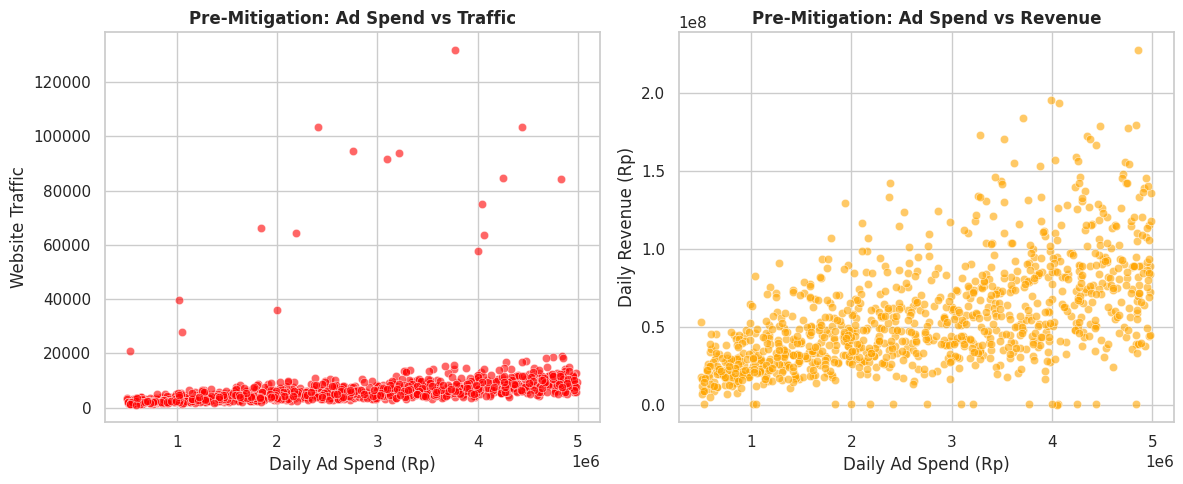

In [ ]:
# Deteksi outlier dengan scatter plot (seperti mentor)
print("="*60)
print("📈 OUTLIER DETECTION - PRE MITIGATION")
print("="*60)

# Statistik deskriptif sebelum mitigasi
print("\n📊 Statistik deskriptif sebelum mitigasi:")
print(df[['Daily_Ad_Spend', 'Website_Traffic', 'Daily_Revenue']].describe())

# Scatter plot untuk deteksi outlier
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.scatterplot(data=df, x='Daily_Ad_Spend', y='Website_Traffic', alpha=0.6, color='red')
plt.title("Pre-Mitigation: Ad Spend vs Traffic", fontweight='bold')
plt.xlabel("Daily Ad Spend (Rp)")
plt.ylabel("Website Traffic")

plt.subplot(1, 2, 2)
sns.scatterplot(data=df, x='Daily_Ad_Spend', y='Daily_Revenue', alpha=0.6, color='orange')
plt.title("Pre-Mitigation: Ad Spend vs Revenue", fontweight='bold')
plt.xlabel("Daily Ad Spend (Rp)")
plt.ylabel("Daily Revenue (Rp)")

plt.tight_layout()
plt.show()

# **4. OUTLIER MITIGATION (IQR Method)**

In [ ]:
# Mitigasi outlier menggunakan metode IQR (seperti mentor)
print("="*60)
print("🎯 OUTLIER MITIGATION - IQR METHOD")
print("="*60)

# Hitung IQR untuk Website_Traffic
Q1_traffic = df['Website_Traffic'].quantile(0.25)
Q3_traffic = df['Website_Traffic'].quantile(0.75)
IQR_traffic = Q3_traffic - Q1_traffic
lower_traffic = Q1_traffic - 1.5 * IQR_traffic
upper_traffic = Q3_traffic + 1.5 * IQR_traffic

print(f"\n📊 Website_Traffic:")
print(f"   Q1: {Q1_traffic:.2f}")
print(f"   Q3: {Q3_traffic:.2f}")
print(f"   IQR: {IQR_traffic:.2f}")
print(f"   Batas bawah: {lower_traffic:.2f}")
print(f"   Batas atas: {upper_traffic:.2f}")

# Hitung IQR untuk Daily_Ad_Spend
Q1_adspend = df['Daily_Ad_Spend'].quantile(0.25)
Q3_adspend = df['Daily_Ad_Spend'].quantile(0.75)
IQR_adspend = Q3_adspend - Q1_adspend
upper_adspend = Q3_adspend + 1.5 * IQR_adspend

print(f"\n📊 Daily_Ad_Spend:")
print(f"   Batas atas (1.5 IQR): {upper_adspend:.2f}")

# Terapkan filter
df_clean = df[
    (df['Website_Traffic'] <= upper_traffic) &
    (df['Daily_Ad_Spend'] <= upper_adspend)
].copy()

print(f"\n✅ Jumlah data sebelum mitigasi: {len(df)}")
print(f"✅ Jumlah data setelah mitigasi: {len(df_clean)}")
print(f"✅ Data yang terhapus: {len(df) - len(df_clean)} ({((len(df)-len(df_clean))/len(df)*100):.1f}%)")

🎯 OUTLIER MITIGATION - IQR METHOD

📊 Website_Traffic:
   Q1: 3564.50
   Q3: 7657.25
   IQR: 4092.75
   Batas bawah: -2574.62
   Batas atas: 13796.38

📊 Daily_Ad_Spend:
   Batas atas (1.5 IQR): 7359064.25

✅ Jumlah data sebelum mitigasi: 1104
✅ Jumlah data setelah mitigasi: 1023
✅ Data yang terhapus: 81 (7.3%)


# **5. POST-MITIGATION VALIDATION**

In [ ]:
# 5. POST-MITIGATION VALIDATION
print("="*60)
print("🎯 VALIDASI DATA SETELAH MITIGASI")
print("="*60)

# Gunakan df_clean (hasil dari mitigasi outlier)
diskon = df_clean[df_clean['Promo_Active'] == 'DISKON 20%']['Daily_Revenue']
cashback = df_clean[df_clean['Promo_Active'] == 'CASHBACK 50K']['Daily_Revenue']

print(f"\n✅ Diskon 20%: {len(diskon)} data")
print(f"✅ Cashback 50K: {len(cashback)} data")
print(f"✅ Total: {len(diskon) + len(cashback)} dari {len(df_clean)} data")

print(f"\n📊 Statistik Deskriptif:")
print(f"Diskon 20%  -> Mean = Rp {diskon.mean():,.0f}, Median = Rp {diskon.median():,.0f}")
print(f"Cashback 50K -> Mean = Rp {cashback.mean():,.0f}, Median = Rp {cashback.median():,.0f}")
print(f"Selisih mean = Rp {diskon.mean() - cashback.mean():,.0f}")

🎯 VALIDASI DATA SETELAH MITIGASI

✅ Diskon 20%: 553 data
✅ Cashback 50K: 470 data
✅ Total: 1023 dari 1023 data

📊 Statistik Deskriptif:
Diskon 20%  -> Mean = Rp 66,807,929, Median = Rp 61,511,090
Cashback 50K -> Mean = Rp 41,686,601, Median = Rp 37,536,191
Selisih mean = Rp 25,121,329


In [ ]:
# Verifikasi akhir dataset yang sudah bersih
print("="*60)
print("📋 VERIFIKASI AKHIR DATASET")
print("="*60)

print("\n📊 Distribusi Promo setelah cleaning:")
print(df_clean['Promo_Active'].value_counts())

print("\n📊 Info dataset akhir:")
print(df_clean.info())

print("\n📊 5 Data teratas setelah semua cleaning:")
print(df_clean.head())

# Cek missing value tersisa
print("\n📊 Missing value per kolom:")
print(df_clean.isna().sum())

📋 VERIFIKASI AKHIR DATASET

📊 Distribusi Promo setelah cleaning:
Promo_Active
DISKON 20%      553
CASHBACK 50K    470
Name: count, dtype: int64

📊 Info dataset akhir:
<class 'pandas.core.frame.DataFrame'>
Index: 1023 entries, 0 to 1102
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   Tanggal          1023 non-null   datetime64[ns]
 1   Region_Code      1023 non-null   object        
 2   Promo_Active     1023 non-null   object        
 3   Daily_Ad_Spend   1023 non-null   float64       
 4   Website_Traffic  1023 non-null   int64         
 5   Daily_Revenue    1023 non-null   int64         
dtypes: datetime64[ns](1), float64(1), int64(2), object(2)
memory usage: 55.9+ KB
None

📊 5 Data teratas setelah semua cleaning:
     Tanggal  Region_Code  Promo_Active  Daily_Ad_Spend  Website_Traffic  \
0 2023-09-20  JABODETABEK  CASHBACK 50K       2162246.0             7600   
1 2023-12-16     SULAWESI  

# **Task A: Statistical Significance Testing of Promotional Performance**

In [ ]:
from scipy.stats import ttest_ind

# Pakai data yang SUDAH bersih
diskon = df_clean[df_clean['Promo_Active'] == 'DISKON 20%']['Daily_Revenue']
cashback = df_clean[df_clean['Promo_Active'] == 'CASHBACK 50K']['Daily_Revenue']

# Mean
mean_diskon = diskon.mean()
mean_cashback = cashback.mean()

print("Rata-rata Revenue Diskon 20%:", mean_diskon)
print("Rata-rata Revenue Cashback 50K:", mean_cashback)

# T-Test
t_stat, p_value = ttest_ind(diskon, cashback, equal_var=False)

print("T-Statistic:", t_stat)
print("P-Value:", p_value)

# Keputusan
alpha = 0.05
if p_value < alpha:
    print("Keputusan: Tolak H0 (Perbedaan signifikan)")
else:
    print("Keputusan: Gagal menolak H0 (Tidak signifikan)")

Rata-rata Revenue Diskon 20%: 66807929.381555155
Rata-rata Revenue Cashback 50K: 41686600.55744681
T-Statistic: 14.128658087109422
P-Value: 2.7194800385166117e-41
Keputusan: Tolak H0 (Perbedaan signifikan)


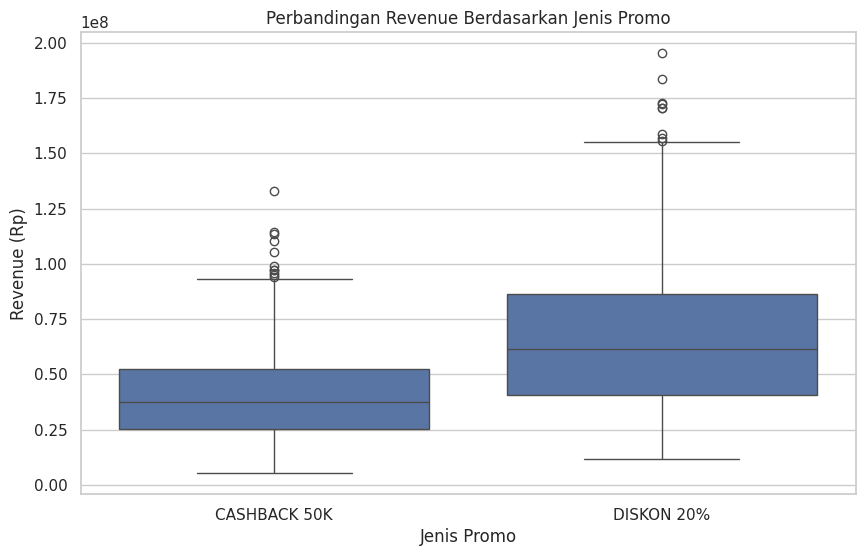

In [ ]:
sns.boxplot(data=df_clean, x='Promo_Active', y='Daily_Revenue')
plt.title("Perbandingan Revenue Berdasarkan Jenis Promo")
plt.xlabel("Jenis Promo")
plt.ylabel("Revenue (Rp)")
plt.show()

In [ ]:
sns.barplot(data=df_clean, x='Promo_Active', y='Daily_Revenue')
plt.title("Rata-rata Revenue per Promo")
plt.xlabel("Jenis Promo")
plt.ylabel("Revenue (Rp)")
plt.show()

NameError: name 'sns' is not defined

Hasil analisis menunjukkan bahwa promo Diskon 20% menghasilkan rata-rata nilai transaksi yang secara signifikan lebih tinggi dibandingkan dengan promo Cashback Rp 50.000.
Dengan tingkat signifikansi 5%, perbedaan ini terbukti sangat kuat secara statistik (p-value < 0.05), sehingga dapat disimpulkan bahwa strategi diskon memberikan dampak yang lebih efektif dalam meningkatkan revenue.

# **Task B: Regression Analysis of Ad Spend Impact on Website Traffic**

In [ ]:
import statsmodels.api as sm

# Variabel
X = df_clean['Daily_Ad_Spend']
y = df_clean['Website_Traffic']

# Tambahin konstanta (intercept)
X = sm.add_constant(X)

# Model regresi
model = sm.OLS(y, X).fit()

# Ringkasan hasil
print(model.summary())

NameError: name 'df_clean' is not defined

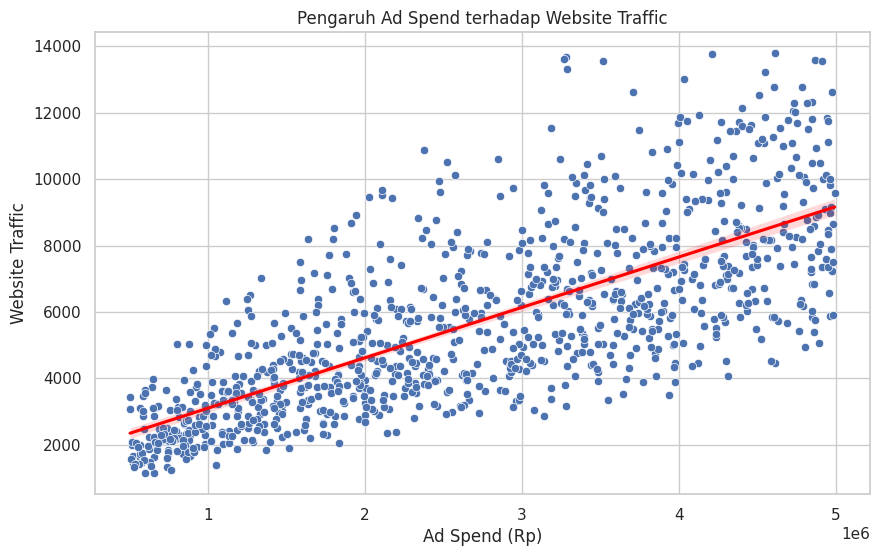

In [ ]:
sns.scatterplot(data=df_clean, x='Daily_Ad_Spend', y='Website_Traffic')
sns.regplot(data=df_clean, x='Daily_Ad_Spend', y='Website_Traffic', scatter=False, color='red')

plt.title("Pengaruh Ad Spend terhadap Website Traffic")
plt.xlabel("Ad Spend (Rp)")
plt.ylabel("Website Traffic")
plt.show()

Hasil analisis regresi menunjukkan bahwa anggaran iklan memiliki pengaruh positif dan signifikan terhadap jumlah pengunjung website. Setiap peningkatan anggaran iklan sebesar Rp1 diperkirakan akan meningkatkan traffic sebesar 0.0015 pengunjung, atau setara dengan sekitar 1.500 pengunjung tambahan untuk setiap kenaikan Rp1.000.000.
Model ini memiliki tingkat kekuatan hubungan yang cukup baik, dengan nilai R² sebesar 0.547, yang menunjukkan bahwa sekitar 54.7% variasi dalam traffic dapat dijelaskan oleh perubahan anggaran iklan. Temuan ini mengindikasikan bahwa investasi dalam iklan merupakan faktor penting dalam mendorong peningkatan traffic.